# Phase 5: Transfer Learning Comparison

In this phase we train transfer-learning models and compare them with the Phase 3 simple CNN using the same Phase 2 train/validation/test split.

The notebook starts with `QUICK_RUN = True` so the pipeline can be checked quickly on CPU. For final results, set `QUICK_RUN = False`, choose whether to use pretrained ImageNet weights, and rerun all cells.

## 1. Setup

Import PyTorch, torchvision transforms, project helpers, and transfer model builders. Finds the project root, sets CPU as the device, defines output folders, and fixes the random seed.

In [2]:
import csv
import sys
from pathlib import Path

from IPython.display import display
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from spectiqai.data import KidneyImageDataset, count_by_class, load_split_csv
from spectiqai.evaluation import (
    binary_classification_metrics,
    collect_predictions,
    create_confusion_matrix_image,
    save_metrics_csv,
    save_predictions_csv,
)
from spectiqai.models import build_transfer_model
from spectiqai.training import (
    create_history_plot,
    evaluate,
    save_checkpoint,
    save_history_csv,
    set_seed,
    train_one_epoch,
)

set_seed(42)
DEVICE = torch.device("cpu")
SPLIT_CSV_PATH = PROJECT_ROOT / "results" / "dataset_splits.csv"
MODEL_ROOT = PROJECT_ROOT / "models" / "transfer_learning"
RESULTS_DIR = PROJECT_ROOT / "results"

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

Project root: c:\Users\smart\Coding World\SpectiqAI
PyTorch version: 2.12.1+cpu
Device: cpu


Phase 5 can access the project code and PyTorch. Next step: configure the experiment.

## 2. Experiment Configuration

Choose the transfer models and training budget. Defines the model list, image size, batch size, epoch count, and whether to freeze feature extractors.

In [3]:
QUICK_RUN = False
USE_PRETRAINED_WEIGHTS = False
FREEZE_FEATURES = True
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0
LEARNING_RATE = 1e-3
EPOCHS = 1 if QUICK_RUN else 5
MAX_TRAIN_BATCHES = 4 if QUICK_RUN else None
MAX_VAL_BATCHES = 2 if QUICK_RUN else None
QUICK_RUN_RECORD_LIMIT = 64
MODELS_TO_RUN = ["resnet50", "efficientnet_b0"]

print(f"Quick run: {QUICK_RUN}")
print(f"Use pretrained weights: {USE_PRETRAINED_WEIGHTS}")
print(f"Freeze feature extractor: {FREEZE_FEATURES}")
print(f"Epochs: {EPOCHS}")
print(f"Models: {MODELS_TO_RUN}")

Quick run: False
Use pretrained weights: False
Freeze feature extractor: True
Epochs: 5
Models: ['resnet50', 'efficientnet_b0']


## 3. Load Train, Validation, and Test Data

Reuse exactly the same split as Phases 3 and 4. Loads `results/dataset_splits.csv`, applies ImageNet-style normalization, and creates DataLoaders.

In [4]:
splits = load_split_csv(SPLIT_CSV_PATH, project_root=PROJECT_ROOT)
train_records = splits["train"]
val_records = splits["validation"]
test_records = splits["test"]

if QUICK_RUN:
    train_records = train_records[:QUICK_RUN_RECORD_LIMIT]
    val_records = val_records[:QUICK_RUN_RECORD_LIMIT]
    test_records = test_records[:QUICK_RUN_RECORD_LIMIT]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = KidneyImageDataset(train_records, transform=train_transform)
val_dataset = KidneyImageDataset(val_records, transform=eval_transform)
test_dataset = KidneyImageDataset(test_records, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train images: {len(train_dataset)} | counts: {count_by_class(train_records)}")
print(f"Validation images: {len(val_dataset)} | counts: {count_by_class(val_records)}")
print(f"Test images: {len(test_dataset)} | counts: {count_by_class(test_records)}")
print(f"Train batches: {len(train_loader)}")

Train images: 7000 | counts: {'Normal': 3500, 'Tumor': 3500}
Validation images: 1500 | counts: {'Normal': 750, 'Tumor': 750}
Test images: 1500 | counts: {'Normal': 750, 'Tumor': 750}
Train batches: 438


## 4. Train Transfer Models

Train ResNet50 and EfficientNet-B0 classification heads on the kidney dataset. Builds each model, resumes from the latest checkpoint if one exists, trains remaining epochs, evaluates on validation data each epoch, saves checkpoints, histories, and curve images.


Training resnet50...
Resuming from resnet50_epoch_5.pt; next epoch is 6.
resnet50 is already trained through epoch 5.


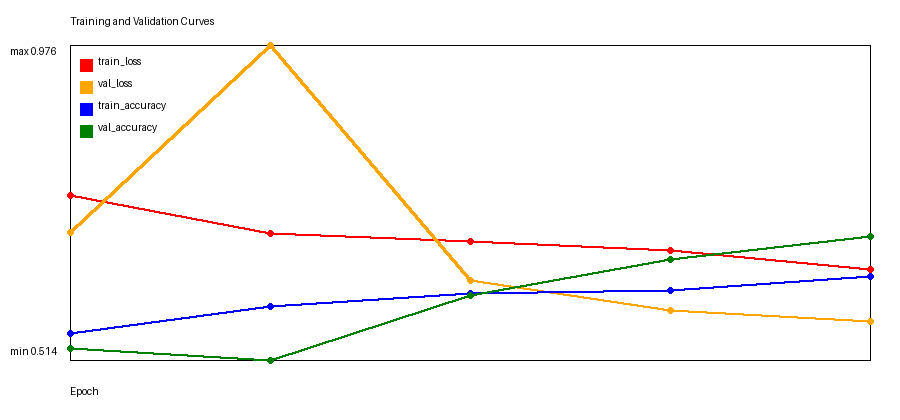


Training efficientnet_b0...
Resuming from efficientnet_b0_epoch_1.pt; next epoch is 2.
  Trained 25 batches...
  Trained 50 batches...
  Trained 75 batches...
  Trained 100 batches...
  Trained 125 batches...
  Trained 150 batches...
  Trained 175 batches...
  Trained 200 batches...
  Trained 225 batches...
  Trained 250 batches...
  Trained 275 batches...
  Trained 300 batches...
  Trained 325 batches...
  Trained 350 batches...
  Trained 375 batches...
  Trained 400 batches...
  Trained 425 batches...
Epoch 2: train loss=0.6839, train acc=0.5630, val loss=0.6927, val acc=0.5220
Saved checkpoint: c:\Users\smart\Coding World\SpectiqAI\models\transfer_learning\efficientnet_b0\efficientnet_b0_epoch_2.pt
  Trained 25 batches...
  Trained 50 batches...
  Trained 75 batches...
  Trained 100 batches...
  Trained 125 batches...
  Trained 150 batches...
  Trained 175 batches...
  Trained 200 batches...
  Trained 225 batches...
  Trained 250 batches...
  Trained 275 batches...
  Trained 300 ba

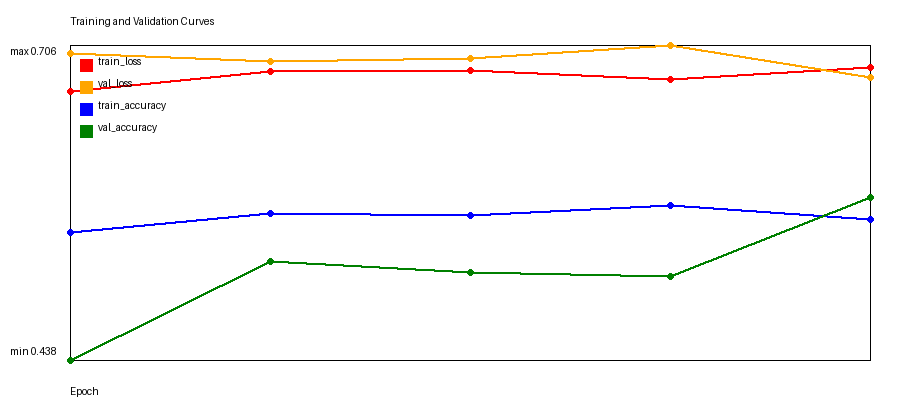

Training complete.


In [5]:
criterion = nn.CrossEntropyLoss()
all_histories = {}

def checkpoint_epoch(checkpoint_path):
    return int(checkpoint_path.stem.rsplit("_", 1)[1])


def latest_checkpoint_path(model_name):
    checkpoint_dir = MODEL_ROOT / model_name
    checkpoints = list(checkpoint_dir.glob(f"{model_name}_epoch_*.pt"))
    if not checkpoints:
        return None
    return max(checkpoints, key=checkpoint_epoch)


def load_existing_history(history_path):
    if not history_path.exists():
        return []

    with history_path.open("r", newline="", encoding="utf-8") as csv_file:
        rows = list(csv.DictReader(csv_file))

    history = []
    for row in rows:
        history.append({
            "epoch": int(row["epoch"]),
            "train_loss": float(row["train_loss"]),
            "train_accuracy": float(row["train_accuracy"]),
            "val_loss": float(row["val_loss"]),
            "val_accuracy": float(row["val_accuracy"]),
        })
    return history


for model_name in MODELS_TO_RUN:
    print(f"\nTraining {model_name}...")
    model = build_transfer_model(
        model_name,
        num_classes=2,
        pretrained=USE_PRETRAINED_WEIGHTS,
        freeze_features=FREEZE_FEATURES,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=LEARNING_RATE,
    )

    history_path = RESULTS_DIR / f"{model_name}_history.csv"
    history = load_existing_history(history_path)
    resume_checkpoint_path = latest_checkpoint_path(model_name)
    start_epoch = 1

    if resume_checkpoint_path is not None:
        checkpoint = torch.load(resume_checkpoint_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = int(checkpoint["epoch"]) + 1
        history = [row for row in history if int(row["epoch"]) < start_epoch]
        print(f"Resuming from {resume_checkpoint_path.name}; next epoch is {start_epoch}.")

    if start_epoch > EPOCHS:
        print(f"{model_name} is already trained through epoch {EPOCHS}.")
        all_histories[model_name] = history
        if history:
            curve_image = create_history_plot(history, RESULTS_DIR / f"{model_name}_training_curves.png")
            display(curve_image)
        continue

    for epoch in range(start_epoch, EPOCHS + 1):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
            max_batches=MAX_TRAIN_BATCHES,
        )
        val_metrics = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
            max_batches=MAX_VAL_BATCHES,
        )

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
        }
        history.append(row)
        print(
            f"Epoch {epoch}: "
            f"train loss={row['train_loss']:.4f}, train acc={row['train_accuracy']:.4f}, "
            f"val loss={row['val_loss']:.4f}, val acc={row['val_accuracy']:.4f}"
        )

        checkpoint_path = MODEL_ROOT / model_name / f"{model_name}_epoch_{epoch}.pt"
        save_checkpoint(model, optimizer, epoch, row, checkpoint_path)
        save_history_csv(history, history_path)
        print(f"Saved checkpoint: {checkpoint_path}")

    all_histories[model_name] = history
    save_history_csv(history, history_path)
    curve_image = create_history_plot(history, RESULTS_DIR / f"{model_name}_training_curves.png")
    display(curve_image)

print("Training complete.")

## 5. Evaluate Transfer Models on the Test Set

Evaluate each trained transfer model using the same metrics as Phase 4. Loads the latest available checkpoint, collects predictions on the test set, computes accuracy, precision, recall, F1 score, saves prediction CSVs, and saves confusion matrix images.


Evaluating resnet50...
Loading checkpoint: resnet50_epoch_5.pt


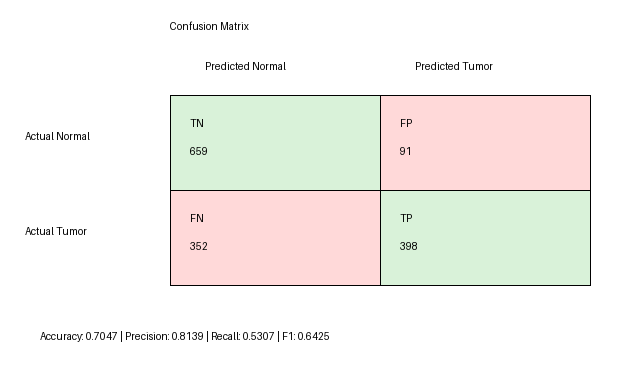

{'model': 'resnet50', 'accuracy': 0.7046666666666667, 'precision': 0.8139059304703476, 'recall': 0.5306666666666666, 'f1_score': 0.6424535916061339, 'true_positive': 398.0, 'true_negative': 659.0, 'false_positive': 91.0, 'false_negative': 352.0}

Evaluating efficientnet_b0...
Loading checkpoint: efficientnet_b0_epoch_5.pt


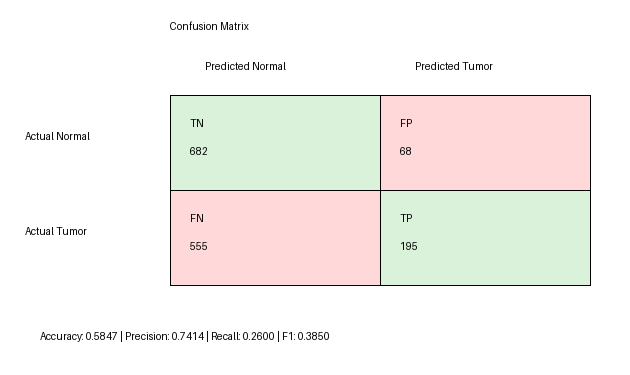

{'model': 'efficientnet_b0', 'accuracy': 0.5846666666666667, 'precision': 0.7414448669201521, 'recall': 0.26, 'f1_score': 0.384995064165844, 'true_positive': 195.0, 'true_negative': 682.0, 'false_positive': 68.0, 'false_negative': 555.0}
Transfer model evaluation complete.


In [6]:
transfer_results = []

if "latest_checkpoint_path" not in globals():
    def checkpoint_epoch(checkpoint_path):
        return int(checkpoint_path.stem.rsplit("_", 1)[1])

    def latest_checkpoint_path(model_name):
        checkpoint_dir = MODEL_ROOT / model_name
        checkpoints = list(checkpoint_dir.glob(f"{model_name}_epoch_*.pt"))
        if not checkpoints:
            return None
        return max(checkpoints, key=checkpoint_epoch)


for model_name in MODELS_TO_RUN:
    print(f"\nEvaluating {model_name}...")
    model = build_transfer_model(
        model_name,
        num_classes=2,
        pretrained=False,
        freeze_features=FREEZE_FEATURES,
    ).to(DEVICE)

    checkpoint_path = latest_checkpoint_path(model_name)
    if checkpoint_path is None:
        raise FileNotFoundError(f"No checkpoint found for {model_name}. Train it first.")
    print(f"Loading checkpoint: {checkpoint_path.name}")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    true_labels, predicted_labels, tumor_probabilities = collect_predictions(model, test_loader, DEVICE)
    metrics = binary_classification_metrics(true_labels, predicted_labels)
    metrics = {"model": model_name, **metrics}
    transfer_results.append(metrics)

    save_metrics_csv(metrics, RESULTS_DIR / f"{model_name}_test_metrics.csv")
    save_predictions_csv(
        true_labels,
        predicted_labels,
        tumor_probabilities,
        RESULTS_DIR / f"{model_name}_test_predictions.csv",
    )
    confusion_image = create_confusion_matrix_image(metrics, RESULTS_DIR / f"{model_name}_confusion_matrix.png")
    display(confusion_image)
    print(metrics)

print("Transfer model evaluation complete.")

## 6. Compare With the Simple CNN

Put the Phase 5 transfer models next to the Phase 4 simple CNN result. Reads `simple_cnn_test_metrics.csv` if available, combines it with the transfer-model metrics, and saves a comparison CSV.

In [7]:
comparison_rows = []
simple_metrics_path = RESULTS_DIR / "simple_cnn_test_metrics.csv"

if simple_metrics_path.exists():
    with simple_metrics_path.open("r", newline="", encoding="utf-8") as csv_file:
        reader = csv.DictReader(csv_file)
        for row in reader:
            comparison_rows.append({"model": "simple_cnn", **row})
else:
    print("Simple CNN metrics not found; run Phase 4 to include that baseline.")

comparison_rows.extend(transfer_results)

metric_names = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "true_positive",
    "true_negative",
    "false_positive",
    "false_negative",
]

for row in comparison_rows:
    for metric_name in metric_names:
        row[metric_name] = float(row[metric_name])

comparison_rows = sorted(comparison_rows, key=lambda row: row["f1_score"], reverse=True)
comparison_path = RESULTS_DIR / "phase5_model_comparison.csv"

with comparison_path.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=["model", *metric_names])
    writer.writeheader()
    writer.writerows(comparison_rows)

for row in comparison_rows:
    print(
        f"{row['model']}: "
        f"accuracy={row['accuracy']:.4f}, precision={row['precision']:.4f}, "
        f"recall={row['recall']:.4f}, f1={row['f1_score']:.4f}"
    )

print(f"Saved comparison: {comparison_path}")

simple_cnn: accuracy=0.9893, precision=0.9791, recall=1.0000, f1=0.9894
resnet50: accuracy=0.7047, precision=0.8139, recall=0.5307, f1=0.6425
efficientnet_b0: accuracy=0.5847, precision=0.7414, recall=0.2600, f1=0.3850
Saved comparison: c:\Users\smart\Coding World\SpectiqAI\results\phase5_model_comparison.csv


## Phase 5 Completion Checklist

Verify that the following outputs have been generated:
- `results/phase5_model_comparison.csv` compares the simple CNN with ResNet50 and EfficientNet-B0.

Phase 5 is complete when the comparison table is produced from a non-quick run. Next step: analyze the best model's errors and decide whether to fine-tune unfrozen layers, adjust augmentation, or tune the decision threshold.